# Assignment

**Name:** Abhay  
**ID:** 08117702023  
**Class:** BCA V-B  
**Assistant Professor:** Mamta Madan  

---

## Questions based on Logistic Regression

**Instructor:** Mamta Madan  
**Points:** 100  
**Due Date:**

---  

# Q8  Implement logistic regression as done in class for the same data set.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
df = pd.read_csv('/content/Salary_Data.csv')
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [ ]:
df.head()

,YearsExperience,Salary,HighSalary
0,1.1,39343.0,0
1,1.3,46205.0,0
2,1.5,37731.0,0
3,2.0,43525.0,0
4,2.2,39891.0,0


In [ ]:
df.shape

(30, 2)

In [ ]:
# Convert continuous salary into a binary class (1 = High Salary, 0 = Low Salary)
threshold = df['Salary'].median()
df['HighSalary'] = (df['Salary'] > threshold).astype(int)

In [ ]:
X = df[['YearsExperience']]
y = df['HighSalary']

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
# Predictions
y_pred = model.predict(X_test)

In [ ]:
# Evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[3 0]
 [1 5]]

Classification Report:
               precision    recall  f1-score   support

           0       0.75      1.00      0.86         3
           1       1.00      0.83      0.91         6

    accuracy                           0.89         9
   macro avg       0.88      0.92      0.88         9
weighted avg       0.92      0.89      0.89         9



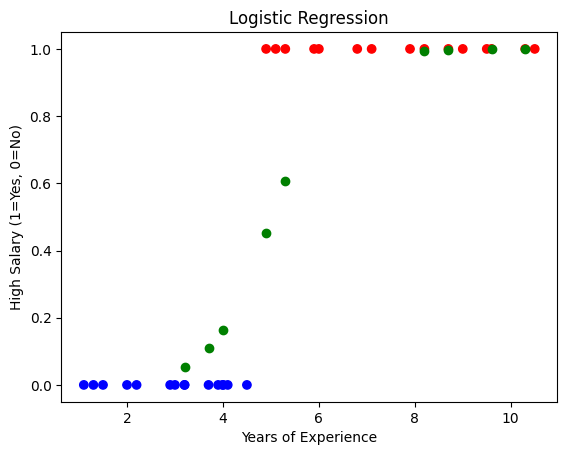

In [ ]:
# Plot decision boundary
plt.scatter(X, y, c=y, cmap='bwr')
plt.plot(X_test, model.predict_proba(X_test)[:,1], 'go')
plt.xlabel("Years of Experience")
plt.ylabel("High Salary (1=Yes, 0=No)")
plt.title("Logistic Regression")
plt.show()

# Q 9 Apply logistic regression on insurance dataset from Kaggle based on age and gender.

In [ ]:
df = pd.read_csv("/content/archive.zip")

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.shape

(1338, 7)

In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
df.drop_duplicates()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [ ]:
# Convert charges into binary class: High (1) if above median, else Low (0)
threshold = df['charges'].median()
df['HighCharges'] = (df['charges'] > threshold).astype(int)

In [ ]:
# Select features: age and sex (convert to numeric)
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
X = df[['age', 'sex']]
y = df['HighCharges']

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
# Predictions
y_pred = model.predict(X_test)

In [ ]:
# Evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[144  63]
 [ 50 145]]

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.70      0.72       207
           1       0.70      0.74      0.72       195

    accuracy                           0.72       402
   macro avg       0.72      0.72      0.72       402
weighted avg       0.72      0.72      0.72       402



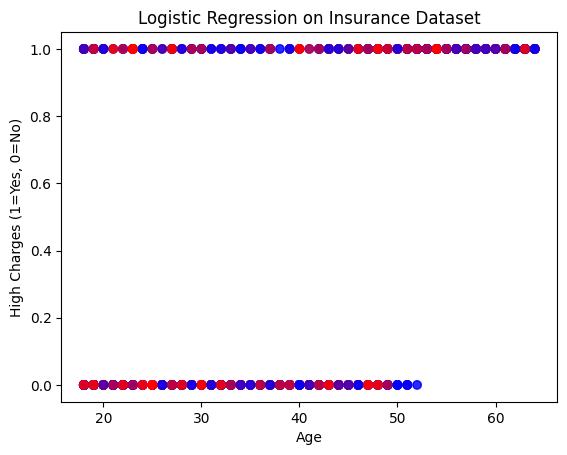

In [ ]:
# Scatter plot of age vs charges classification
plt.scatter(df['age'], df['HighCharges'], c=df['sex'], cmap='bwr', alpha=0.6)
plt.xlabel("Age")
plt.ylabel("High Charges (1=Yes, 0=No)")
plt.title("Logistic Regression on Insurance Dataset")
plt.show()